loads existing SN1987A_broad_clean_1deg.csv.csv, computes local offsets in pc, and estimates the local LMC proper motion from  Gaia sample.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import SkyCoord, SkyOffsetFrame

from pathlib import Path

output_dir = Path("output_files")
fig_dir = Path("figures_broad")
fig_dir.mkdir(exist_ok=True)

D_LMC_kpc = 49.59
D_LMC_pc = D_LMC_kpc * 1000

# Tegkelidis et al. 2025
sn87a = SkyCoord("05h35m27.9884s", "-69d16m11.1134s", frame="icrs")
pmra_87a = 1.60
pmdec_87a = 0.44
pmra_87a_err = 0.15
pmdec_87a_err = 0.09

# R136
r136 = SkyCoord(ra=84.6767920*u.deg, dec=-69.1006110*u.deg, frame="icrs")

df = pd.read_csv(output_dir / "SN1987A_broad_clean_1deg.csv")
df.columns = df.columns.str.strip()

coords = SkyCoord(df["ra"].values*u.deg, df["dec"].values*u.deg, frame="icrs")

# Tangent-plane coordinates centred on SN1987A
frame_87a = SkyOffsetFrame(origin=sn87a)
off = coords.transform_to(frame_87a)

df["x_pc"] = off.lon.to_value(u.rad) * D_LMC_pc     # east
df["y_pc"] = off.lat.to_value(u.rad) * D_LMC_pc     # north
df["sep_87a_pc"] = np.sqrt(df["x_pc"]**2 + df["y_pc"]**2)

# R136 in the same coordinate system
r136_off = r136.transform_to(frame_87a)
x_r136_pc = r136_off.lon.to_value(u.rad) * D_LMC_pc
y_r136_pc = r136_off.lat.to_value(u.rad) * D_LMC_pc

# Absolute PM difference from SN1987A
df["dpm_abs_87a_masyr"] = np.sqrt((df["pmra"] - pmra_87a)**2 + (df["pmdec"] - pmdec_87a)**2)
df["dv_to_sn87a_kms"] = 4.74047 * D_LMC_kpc * df["dpm_abs_87a_masyr"]

# Estimate local LMC motion from nearby cleaned Gaia stars.
# Use the full sample if already local; otherwise use inside 100 pc.
local = df[df["sep_87a_pc"] < 100].copy()
if len(local) < 20:
    local = df.copy()

pmra_local = np.nanmedian(local["pmra"])
pmdec_local = np.nanmedian(local["pmdec"])

# Robust uncertainty on the local median.
# This is not a final statistical treatment; it is enough for an exploratory shaded region.
pmra_local_sigma = 0.5 * (np.nanpercentile(local["pmra"], 84) - np.nanpercentile(local["pmra"], 16))
pmdec_local_sigma = 0.5 * (np.nanpercentile(local["pmdec"], 84) - np.nanpercentile(local["pmdec"], 16))

pmra_local_err = 1.253 * pmra_local_sigma / np.sqrt(len(local))
pmdec_local_err = 1.253 * pmdec_local_sigma / np.sqrt(len(local))

pmra_rel_87a = pmra_87a - pmra_local
pmdec_rel_87a = pmdec_87a - pmdec_local

print("N local =", len(local))
print("Local median PMRA* =", pmra_local, "+/-", pmra_local_err, "mas/yr")
print("Local median PMDec =", pmdec_local, "+/-", pmdec_local_err, "mas/yr")
print("SN1987A residual PMRA* =", pmra_rel_87a, "mas/yr")
print("SN1987A residual PMDec =", pmdec_rel_87a, "mas/yr")

mu_rel = np.sqrt(pmra_rel_87a**2 + pmdec_rel_87a**2)
v_rel = 4.74047 * D_LMC_kpc * mu_rel
print("Residual transverse speed =", v_rel, "km/s")

N local = 4242
Local median PMRA* = 1.6825553960008923 +/- 0.005192353857461448 mas/yr
Local median PMDec = 0.5674093516006635 +/- 0.0049697666661664966 mas/yr
SN1987A residual PMRA* = -0.08255539600089223 mas/yr
SN1987A residual PMDec = -0.12740935160066352 mas/yr
Residual transverse speed = 35.6892306476986 km/s


“radius that 87A could have come from” calculation and plot

In [3]:
# ---- Derived velocity columns used by later plots ----

masyr_to_kms = 4.74047 * D_LMC_kpc

# Difference from the absolute SN1987A proper motion
df["dpm_vs_sn87a_masyr"] = np.hypot(
    df["pmra"] - pmra_87a,
    df["pmdec"] - pmdec_87a
)
df["dv_to_sn87a_kms"] = masyr_to_kms * df["dpm_vs_sn87a_masyr"]

# Keep the old column name, because several existing cells use it
df["dpm_abs_87a_masyr"] = df["dpm_vs_sn87a_masyr"]
df["dv_to_sn87a_kms"] = df["dv_to_sn87a_kms"]

# Speed relative to the local LMC median motion
df["dpm_vs_local_masyr"] = np.hypot(
    df["pmra"] - pmra_local,
    df["pmdec"] - pmdec_local
)
df["dv_to_local_kms"] = masyr_to_kms * df["dpm_vs_local_masyr"]

# Alias for the name I previously used by mistake
# This means: velocity difference from SN1987A, in the local-subtracted frame.
# Algebraically this is the same as dv_to_sn87a_kms.
df["dv_local_resid_kms"] = df["dv_to_sn87a_kms"]

print("Velocity columns now available:")
print([
    "dv_to_sn87a_kms",
    "dv_to_sn87a_kms",
    "dv_to_local_kms",
    "dv_local_resid_kms"
])

Velocity columns now available:
['dv_abs_87a_kms', 'dv_vs_sn87a_kms', 'dv_vs_local_kms', 'dv_local_resid_kms']


,age_Myr,v_kms,radius_pc,radius_deg,radius_arcmin
0,10,10,102.27120,0.118163,7.089786
1,10,20,204.54240,0.236326,14.179572
2,10,30,306.81360,0.354489,21.269358
3,10,50,511.35600,0.590815,35.448930
4,10,100,1022.71200,1.181631,70.897860
5,12,10,122.72544,0.141796,8.507743
6,12,20,245.45088,0.283591,17.015486
7,12,30,368.17632,0.425387,25.523230
8,12,50,613.62720,0.708979,42.538716
9,12,100,1227.25440,1.417957,85.077432


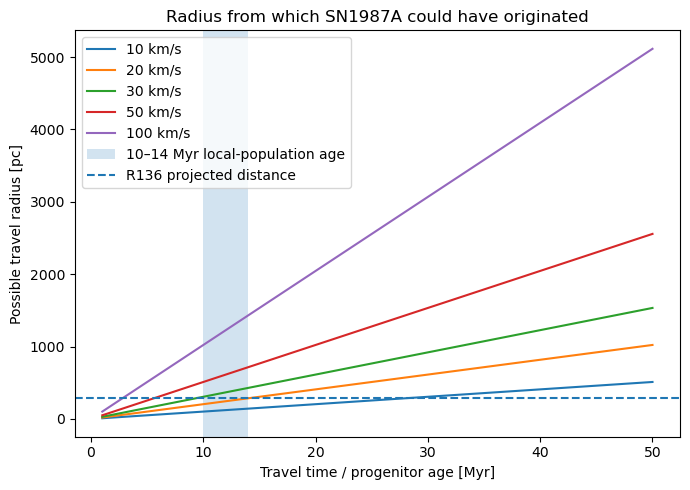

In [4]:
def travel_radius_pc(v_kms, age_myr):
    # 1 km/s = 1.022712 pc/Myr
    return v_kms * 1.022712 * age_myr

def pc_to_deg(r_pc):
    return np.degrees(r_pc / D_LMC_pc)

ages = np.array([10, 12, 14, 30, 40])
velocities = np.array([10, 20, 30, 50, 100])

rows = []
for age in ages:
    for v in velocities:
        r_pc = travel_radius_pc(v, age)
        rows.append({
            "age_Myr": age,
            "v_kms": v,
            "radius_pc": r_pc,
            "radius_deg": pc_to_deg(r_pc),
            "radius_arcmin": 60 * pc_to_deg(r_pc)
        })

reach = pd.DataFrame(rows)
display(reach)

plt.figure(figsize=(7, 5))
for v in velocities:
    ages_plot = np.linspace(1, 50, 300)
    r_plot = travel_radius_pc(v, ages_plot)
    plt.plot(ages_plot, r_plot, label=f"{v} km/s")

plt.axvspan(10, 14, alpha=0.2, label="10–14 Myr local-population age")
plt.axhline(np.sqrt(x_r136_pc**2 + y_r136_pc**2), linestyle="--", label="R136 projected distance")
plt.xlabel("Travel time / progenitor age [Myr]")
plt.ylabel("Possible travel radius [pc]")
plt.title("Radius from which SN1987A could have originated")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "origin_radius_vs_age_broad.png", dpi=300)
plt.show()

main sky plot with reach circles

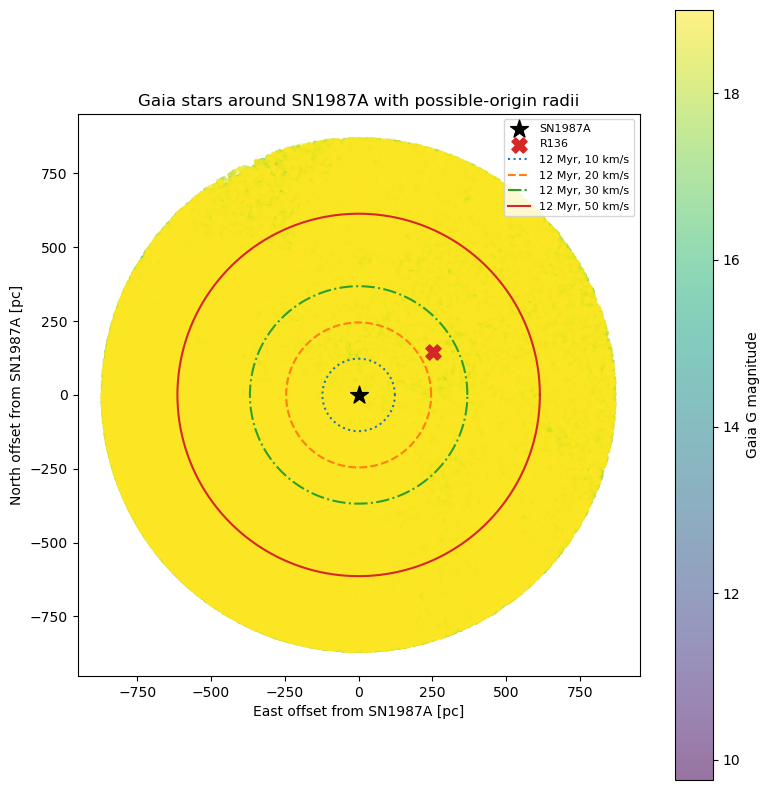

In [5]:
def draw_circle_pc(ax, radius_pc, **kwargs):
    theta = np.linspace(0, 2*np.pi, 500)
    ax.plot(radius_pc*np.cos(theta), radius_pc*np.sin(theta), **kwargs)

fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(
    df["x_pc"], df["y_pc"],
    c=df["phot_g_mean_mag"],
    s=8, alpha=0.55
)

ax.scatter(0, 0, marker="*", s=180, color="black", label="SN1987A")
ax.scatter(x_r136_pc, y_r136_pc, marker="X", s=120, color="tab:red", label="R136")

# Physically motivated travel radii for 12 Myr
for v, ls in [(10, ":"), (20, "--"), (30, "-."), (50, "-")]:
    r = travel_radius_pc(v, 12)
    draw_circle_pc(ax, r, linestyle=ls, linewidth=1.5, label=f"12 Myr, {v} km/s")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("East offset from SN1987A [pc]")
ax.set_ylabel("North offset from SN1987A [pc]")
ax.set_title("Gaia stars around SN1987A with possible-origin radii")
ax.legend(loc="upper right", fontsize=8)

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Gaia G magnitude")

plt.tight_layout()
plt.savefig(fig_dir / "sn1987a_possible_origin_radii_broad.png", dpi=300)
plt.show()

abover: radius_deg = 0.10. below, zoomed in to the actual queried region

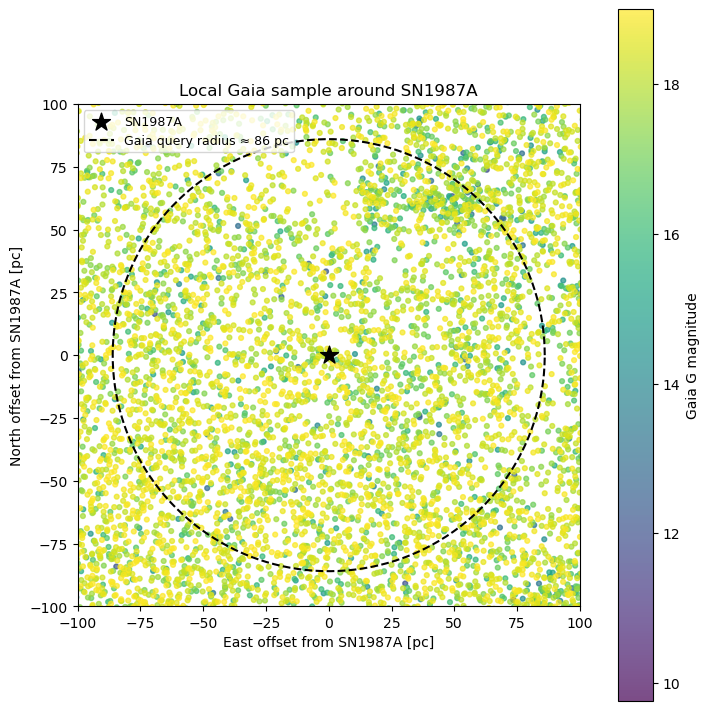

In [6]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

sc = ax.scatter(
    df["x_pc"], df["y_pc"],
    c=df["phot_g_mean_mag"],
    s=12, alpha=0.7
)

ax.scatter(0, 0, marker="*", s=180, color="black", label="SN1987A")

# Show the actual Gaia query radius
query_radius_pc = 86
theta = np.linspace(0, 2*np.pi, 500)
ax.plot(
    query_radius_pc*np.cos(theta),
    query_radius_pc*np.sin(theta),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Gaia query radius ≈ 86 pc"
)

ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("East offset from SN1987A [pc]")
ax.set_ylabel("North offset from SN1987A [pc]")
ax.set_title("Local Gaia sample around SN1987A")

ax.legend(fontsize=9)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Gaia G magnitude")

plt.show()

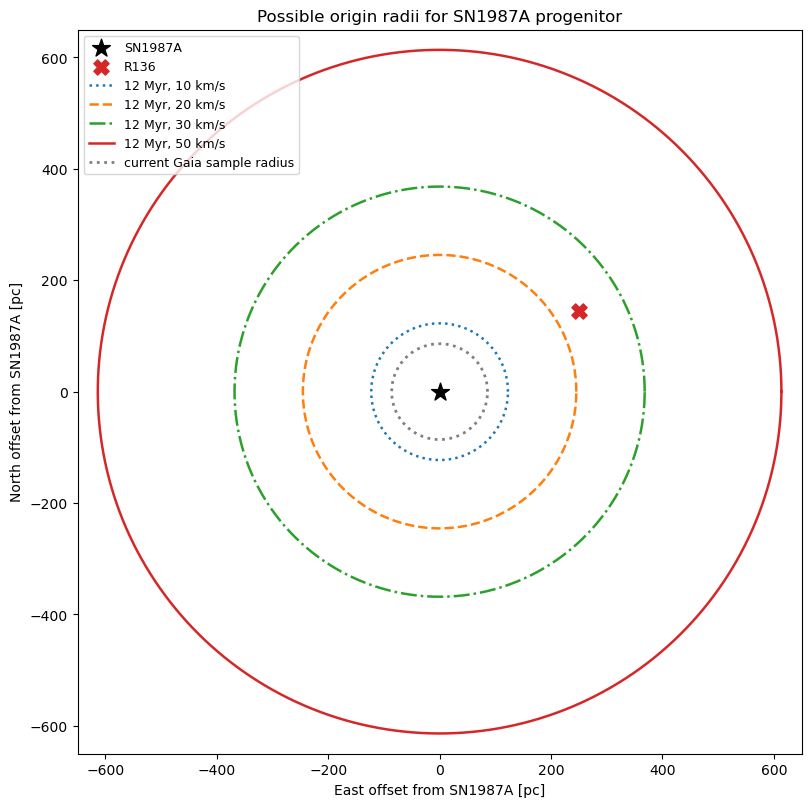

In [7]:
fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)

ax.scatter(0, 0, marker="*", s=180, color="black", label="SN1987A")
ax.scatter(x_r136_pc, y_r136_pc, marker="X", s=120, color="tab:red", label="R136")

for v, ls in [(10, ":"), (20, "--"), (30, "-."), (50, "-")]:
    r = travel_radius_pc(v, 12)
    theta = np.linspace(0, 2*np.pi, 500)
    ax.plot(
        r*np.cos(theta),
        r*np.sin(theta),
        linestyle=ls,
        linewidth=1.8,
        label=f"12 Myr, {v} km/s"
    )

# Also show current small Gaia catalogue coverage
query_radius_pc = 86
ax.plot(
    query_radius_pc*np.cos(theta),
    query_radius_pc*np.sin(theta),
    color="grey",
    linestyle=":",
    linewidth=2,
    label="current Gaia sample radius"
)

ax.set_xlim(-650, 650)
ax.set_ylim(-650, 650)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("East offset from SN1987A [pc]")
ax.set_ylabel("North offset from SN1987A [pc]")
ax.set_title("Possible origin radii for SN1987A progenitor")

ax.legend(fontsize=9)
plt.show()

shaded region around the arrow. This uses Monte Carlo sampling of the proper-motion uncertainty and the age range 12 ± 2 Myr. It plots a back-projection arrow and shades the possible origin region.

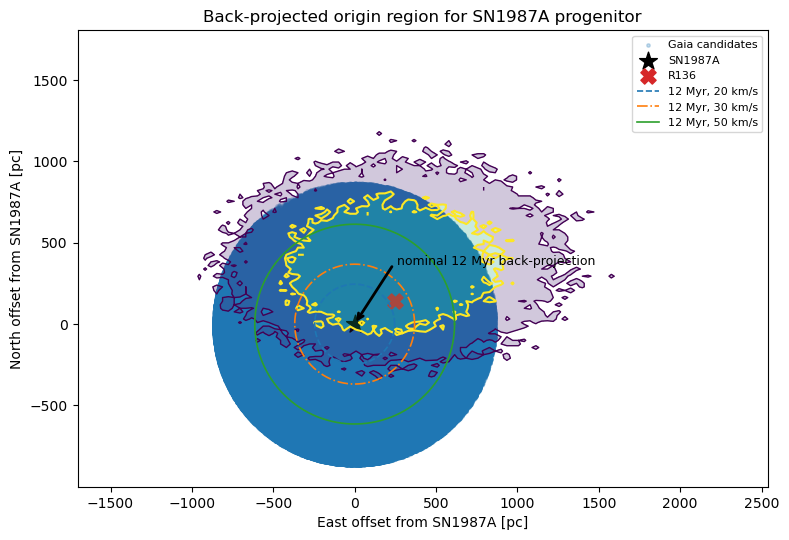

In [8]:
def masyr_to_pc_over_time(mu_masyr, age_myr):
    v_kms = 4.74047 * D_LMC_kpc * mu_masyr
    return v_kms * 1.022712 * age_myr

rng = np.random.default_rng(12345)
n_mc = 50000

# Age range motivated by Panagia et al.
age_samples = rng.normal(12.0, 2.0, n_mc)
age_samples = age_samples[(age_samples > 6) & (age_samples < 20)]

n_mc = len(age_samples)

pmra_87a_s = rng.normal(pmra_87a, pmra_87a_err, n_mc)
pmdec_87a_s = rng.normal(pmdec_87a, pmdec_87a_err, n_mc)

pmra_local_s = rng.normal(pmra_local, pmra_local_err, n_mc)
pmdec_local_s = rng.normal(pmdec_local, pmdec_local_err, n_mc)

pmra_rel_s = pmra_87a_s - pmra_local_s
pmdec_rel_s = pmdec_87a_s - pmdec_local_s

# Back-projected origin = current position - relative displacement
origin_x_s = -masyr_to_pc_over_time(pmra_rel_s, age_samples)
origin_y_s = -masyr_to_pc_over_time(pmdec_rel_s, age_samples)

# Nominal 12 Myr arrow
origin_x_nom = -masyr_to_pc_over_time(pmra_rel_87a, 12.0)
origin_y_nom = -masyr_to_pc_over_time(pmdec_rel_87a, 12.0)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(df["x_pc"], df["y_pc"], s=6, alpha=0.25, label="Gaia candidates")
ax.scatter(0, 0, marker="*", s=180, color="black", label="SN1987A")
ax.scatter(x_r136_pc, y_r136_pc, marker="X", s=120, color="tab:red", label="R136")

# 2D density of possible origin points
H, xedges, yedges = np.histogram2d(origin_x_s, origin_y_s, bins=120)
xcent = 0.5 * (xedges[:-1] + xedges[1:])
ycent = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(xcent, ycent)

# Highest-density levels for approximate 68% and 95% regions
vals = np.sort(H.ravel())[::-1]
cdf = np.cumsum(vals) / np.sum(vals)

level68 = vals[np.searchsorted(cdf, 0.68)]
level95 = vals[np.searchsorted(cdf, 0.95)]

ax.contourf(
    X, Y, H.T,
    levels=[level95, level68, H.max()],
    alpha=0.25
)

ax.contour(
    X, Y, H.T,
    levels=[level95, level68],
    linewidths=[1.0, 1.5]
)

ax.annotate(
    "",
    xy=(0, 0),                         # current SN1987A position
    xytext=(origin_x_nom, origin_y_nom),# possible birth/origin point
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

ax.text(origin_x_nom, origin_y_nom, " nominal 12 Myr back-projection", fontsize=9)

# Add 12 Myr travel-radius references
for v, ls in [(20, "--"), (30, "-."), (50, "-")]:
    draw_circle_pc(ax, travel_radius_pc(v, 12), linestyle=ls, linewidth=1.2, label=f"12 Myr, {v} km/s")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("East offset from SN1987A [pc]")
ax.set_ylabel("North offset from SN1987A [pc]")
ax.set_title("Back-projected origin region for SN1987A progenitor")
ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.savefig(fig_dir / "sn1987a_backprojection_shaded_region_broad.png", dpi=300)
plt.show()

Monte Carlo back-projection of the possible SN 1987A progenitor origin. The arrow shows the nominal 12 Myr traceback using the residual proper motion of SN 1987A after subtracting the local LMC motion estimated from nearby Gaia stars. The blue shaded region shows the uncertainty envelope obtained by sampling the SN 1987A proper-motion errors, the uncertainty in the local Gaia median proper motion, and an assumed progenitor age of 12 ± 2 Myr. The shaded region should be interpreted as a possible-origin region under these assumptions, not as a detected stellar overdensity.

If the arrow is short or the shaded region is huge, that is not a failure. It means the measured proper motion of SN 1987A is very close to the local LMC motion, so the residual motion is weak and uncertain.

The white star at the centre is the current position of SN 1987A. The red cross is R136. The dashed/solid circles show how far a star could travel in 12 Myr if it had a transverse velocity of 20, 30, or 50 km/s. The white arrow is the nominal back-projection of the SN 1987A progenitor over 12 Myr, after subtracting the local LMC proper motion. The coloured shaded/contour region is the Monte Carlo uncertainty region for that back-projected origin.

Using the current residual proper motion estimate, the nominal 12 Myr traceback points roughly northeast of SN 1987A, in the general direction of R136, but the uncertainty region is very broad.”

More specifically, the arrow points to a location somewhat north-east of SN 1987A, and R136 lies in roughly the same quadrant. That is mildly interesting. It means the nominal residual motion is not pointing in a completely unrelated direction. However, the shaded uncertainty region is so large that this plot does not provide a strong origin constraint.

The most important thing to say is that the shaded region overlaps a very large area, including the SN 1987A position itself and regions far beyond R136. This means that, with the current assumptions, the traceback is dominated by uncertainty. We cannot claim “the progenitor came from here.

This figure shows a Monte Carlo back-projection of the possible SN 1987A progenitor origin. The arrow gives the nominal 12 Myr traceback direction after subtracting the local LMC proper motion. The coloured contours show the uncertainty envelope obtained by sampling the proper-motion uncertainties and the assumed 12 ± 2 Myr age range. The result suggests a nominal motion toward the north-east, roughly in the direction of R136, but the uncertainty region is broad. Therefore, this plot does not identify a unique birth site; rather, it shows that proper motion alone currently gives only a weak constraint on the progenitor origin.

The nominal direction is northeast.

R136 lies near the nominal direction, but this is not strong evidence of an R136 origin.

The 20, 30, and 50 km/s circles show that R136 is reachable within 12 Myr at a modest velocity of around 20–30 km/s.

The uncertainty region extends much farther than the physically motivated 12 Myr / 50 km/s travel circle in some directions.

C:\Users\bukow\AppData\Local\Temp\ipykernel_25836\1452572058.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


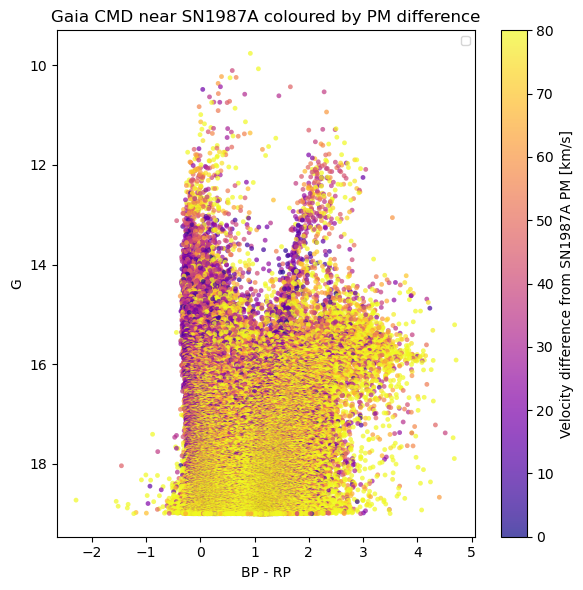

Candidate stars shown: 487


In [19]:
# Plot 1: Gaia CMD coloured by velocity difference from SN1987A

fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    df["bp_rp"],
    df["phot_g_mean_mag"],
    c=df["dv_to_sn87a_kms"],
    vmin=0,
    vmax=80,
    cmap="plasma",
    s=12,
    alpha=0.7,
    edgecolors="none"
)

candidate = df[
    (df["sep_87a_pc"] < 100) &
    (df["dv_to_sn87a_kms"] < 30)
    ].copy()

# the block below circles the ones within 100 pc and with a proper motion difference of less than 30 km/s
# ax.scatter(
#     candidate["bp_rp"],
#     candidate["phot_g_mean_mag"],
#     facecolors="none",
#     edgecolors="black",
#     s=55,
#     linewidths=1.0,
#     label="within 100 pc and 30 km/s"
# )

ax.invert_yaxis()
ax.set_xlabel("BP - RP")
ax.set_ylabel("G")
ax.set_title("Gaia CMD near SN1987A coloured by PM difference")
ax.legend(fontsize=8)

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Velocity difference from SN1987A PM [km/s]")

plt.tight_layout()
plt.savefig(fig_dir / "cmd_sn1987a_candidates_broad_coloured_by_pm.png", dpi=300)
plt.show()

print("Candidate stars shown:", len(candidate))


x-axis: BP - RP colour
y-axis: Gaia G magnitude

The CMD lets me check whether the Gaia stars near SN 1987A include a young stellar population, especially blue massive stars that could plausibly be coeval with the progenitor.

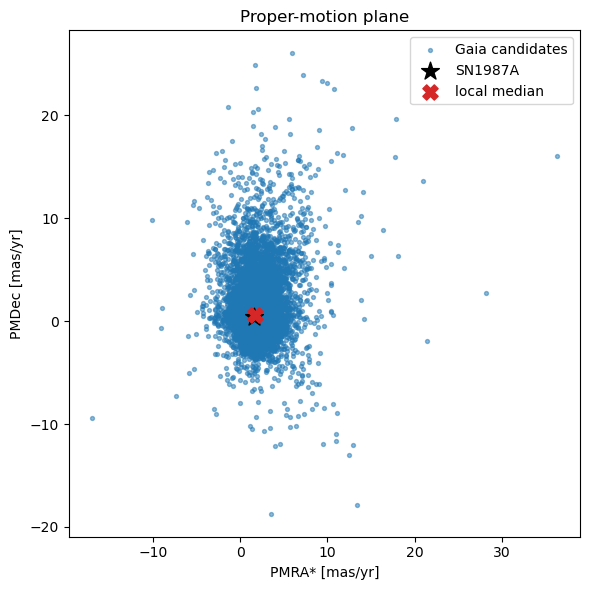

In [10]:


# Plot 2: proper-motion plane
plt.figure(figsize=(6, 6))
plt.scatter(df["pmra"], df["pmdec"], s=8, alpha=0.5, label="Gaia candidates")
plt.scatter(pmra_87a, pmdec_87a, marker="*", s=180, color="black", label="SN1987A")
plt.scatter(pmra_local, pmdec_local, marker="X", s=120, color="tab:red", label="local median")
plt.xlabel("PMRA* [mas/yr]")
plt.ylabel("PMDec [mas/yr]")
plt.title("Proper-motion plane")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "proper_motion_plane_broad.png", dpi=300)
plt.show()

x-axis: PMRA*  [mas/yr]
y-axis: PMDec  [mas/yr]

The proper-motion plane shows whether SN 1987A has a motion distinct from, or consistent with, the local LMC stellar field.

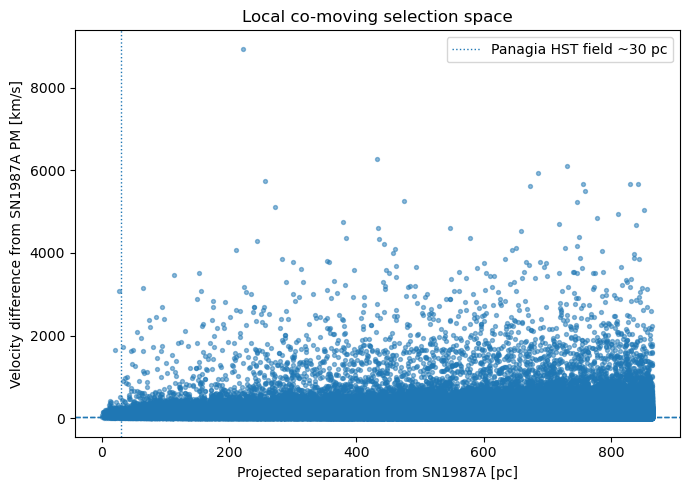

In [11]:



# Plot 3: projected separation vs absolute velocity difference
plt.figure(figsize=(7, 5))
plt.scatter(df["sep_87a_pc"], df["dv_to_sn87a_kms"], s=8, alpha=0.5)
plt.axhline(20, linestyle="--", linewidth=1)
plt.axhline(30, linestyle="--", linewidth=1)
plt.axvline(30, linestyle=":", linewidth=1, label="Panagia HST field ~30 pc")
plt.xlabel("Projected separation from SN1987A [pc]")
plt.ylabel("Velocity difference from SN1987A PM [km/s]")
plt.title("Local co-moving selection space")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "separation_vs_velocity_difference_broad.png", dpi=300)
plt.show()


x-axis: projected distance from SN1987A [pc]
y-axis: velocity difference from SN1987A proper motion [km/s]

This plot helps identify stars that are both near SN 1987A and moving similarly, which are the most plausible local environmental candidates.

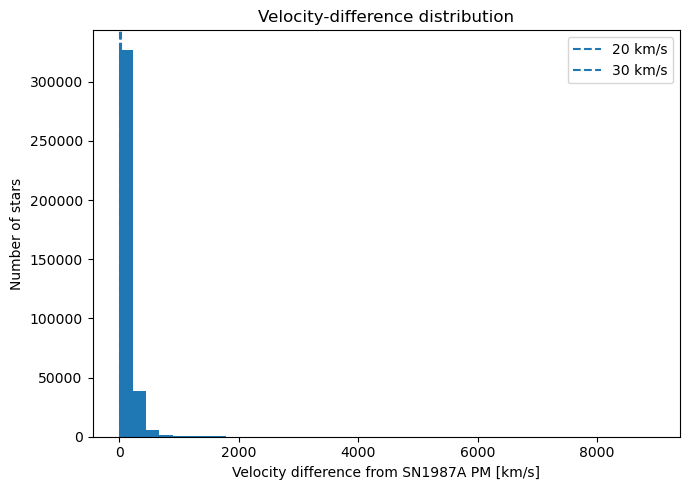

In [12]:


# Plot 4: velocity-difference histogram
plt.figure(figsize=(7, 5))
plt.hist(df["dv_to_sn87a_kms"].dropna(), bins=40)
plt.axvline(20, linestyle="--", label="20 km/s")
plt.axvline(30, linestyle="--", label="30 km/s")
plt.xlabel("Velocity difference from SN1987A PM [km/s]")
plt.ylabel("Number of stars")
plt.title("Velocity-difference distribution")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "velocity_difference_histogram_broad.png", dpi=300)
plt.show()



the x-axis is being stretched by extreme outliers in df["dv_to_sn87a_kms"]. Most stars are clustered near low velocity differences, but a small number have absurdly large values up to ~9000 km/s, so the useful part of the histogram is compressed into the first tiny part of the plot

to inspect the values:

In [13]:
dv = df["dv_to_sn87a_kms"].dropna()

print(dv.describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]))
print("Number above 200 km/s:", (dv > 200).sum())
print("Number above 500 km/s:", (dv > 500).sum())

count    373973.000000
mean        131.412127
std         155.892985
min           0.138873
50%          97.929101
90%         248.182961
95%         331.573812
99%         601.584377
99.9%      2027.776472
max        8941.246131
Name: dv_abs_87a_kms, dtype: float64
Number above 200 km/s: 58774
Number above 500 km/s: 6046


x-axis: velocity difference from SN1987A or from the local residual motion [km/s]
y-axis: number of stars

The velocity distribution tells me how unusual a given velocity difference is, and helps justify the velocity cut used to select co-moving candidates.

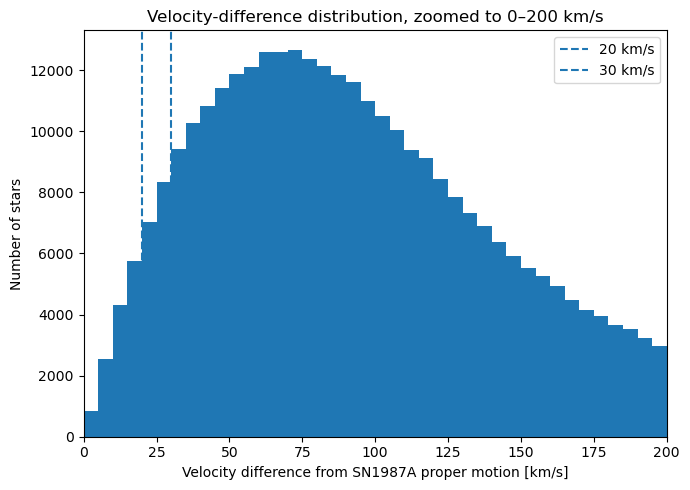

In [14]:
# Plot 4: velocity-difference histogram, zoomed
dv = df["dv_to_sn87a_kms"].dropna()

plt.figure(figsize=(7, 5))
plt.hist(dv, bins=np.linspace(0, 200, 41))

plt.axvline(20, linestyle="--", label="20 km/s")
plt.axvline(30, linestyle="--", label="30 km/s")

plt.xlabel("Velocity difference from SN1987A proper motion [km/s]")
plt.ylabel("Number of stars")
plt.title("Velocity-difference distribution, zoomed to 0–200 km/s")
plt.xlim(0, 200)
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "velocity_difference_histogram_broad_zoomed.png", dpi=300)
plt.show()

In [15]:

import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord

# Distance to LMC
D_LMC_kpc = 49.59
D_LMC_pc = D_LMC_kpc * 1000

# Coordinates
sn87a_coord = SkyCoord("05h35m27.9884s", "-69d16m11.1134s", frame="icrs")
r136_coord = SkyCoord(ra=84.6767920*u.deg, dec=-69.1006110*u.deg, frame="icrs")

# Offset of R136 relative to SN1987A
sep_pc = sn87a_coord.separation(r136_coord).rad * D_LMC_pc
pa = sn87a_coord.position_angle(r136_coord).rad

r136_x_pc = sep_pc * np.sin(pa)   # east offset
r136_y_pc = sep_pc * np.cos(pa)   # north offset

print("R136 offset from SN1987A:")
print("x/east [pc]:", r136_x_pc)
print("y/north [pc]:", r136_y_pc)
print("projected separation [pc]:", np.sqrt(r136_x_pc**2 + r136_y_pc**2))



R136 offset from SN1987A:
x/east [pc]: 250.1352097371921
y/north [pc]: 144.74111444921246
projected separation [pc]: 288.99414070577467


In [16]:
print("Total df rows:", len(df))

fast = df[
    (df["dv_to_sn87a_kms"] > 50) &
    (df["ruwe"] < 1.4) &
    (df["pmra_error"] < 0.2) &
    (df["pmdec_error"] < 0.2)
    ].copy()

print("Fast cleaned rows:", len(fast))
print(df[["dv_to_sn87a_kms", "ruwe", "pmra_error", "pmdec_error"]].describe())

Total df rows: 373973
Fast cleaned rows: 172233
       dv_abs_87a_kms           ruwe     pmra_error    pmdec_error
count   373973.000000  373973.000000  373973.000000  373973.000000
mean       131.412127       1.060210       0.154605       0.173287
std        155.892985       0.095006       0.073924       0.083611
min          0.138873       0.576801       0.011815       0.013203
25%         59.491236       0.997240       0.100727       0.111378
50%         97.929101       1.038672       0.155328       0.173520
75%        156.284969       1.097942       0.199031       0.224244
max       8941.246131       1.399997       1.301083       1.275626


x-axis: east offset from SN1987A [pc]
y-axis: north offset from SN1987A [pc]
colour: velocity difference [km/s]

This map shows whether kinematically similar stars are spatially clustered around SN 1987A or distributed like the general LMC field.

Stars above colour scale limit, >150 km/s: 100470


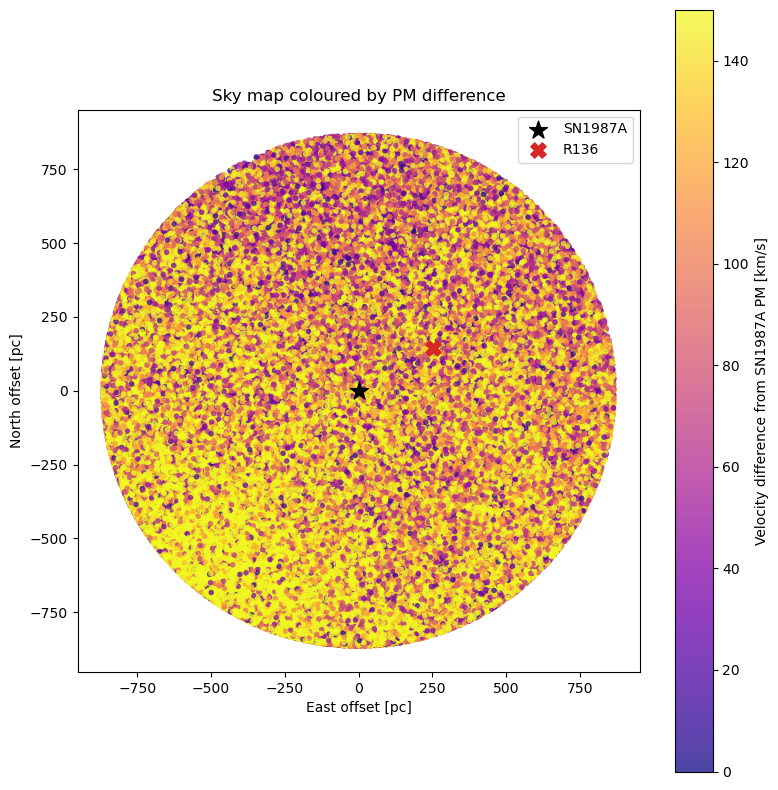

In [17]:
# Plot 5: sky map coloured by velocity difference
# Colour scale clipped so normal stars are not hidden by extreme outliers.

fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(
    df["x_pc"],
    df["y_pc"],
    c=df["dv_to_sn87a_kms"],
    vmin=0,
    vmax=150,
    cmap="plasma",
    s=16,
    alpha=0.75,
    edgecolors="none"
)

ax.scatter(0, 0, marker="*", s=180, color="black", label="SN1987A")
ax.scatter(x_r136_pc, y_r136_pc, marker="X", s=120, color="tab:red", label="R136")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("East offset [pc]")
ax.set_ylabel("North offset [pc]")
ax.set_title("Sky map coloured by PM difference")
ax.legend()

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Velocity difference from SN1987A PM [km/s]")

outliers = df[df["dv_to_sn87a_kms"] > 150]
print("Stars above colour scale limit, >150 km/s:", len(outliers))

plt.tight_layout()
plt.savefig(fig_dir / "sky_map_coloured_by_velocity_difference_broad.png", dpi=300)
plt.show()

Stars plotted as arrows: 280796


C:\Users\bukow\AppData\Local\Temp\ipykernel_25836\2060017128.py:75: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(fig_dir / "residual_pm_vectors_broad_cleaned.png", dpi=300)
C:\Users\bukow\anaconda3\envs\mygaia_win_min\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


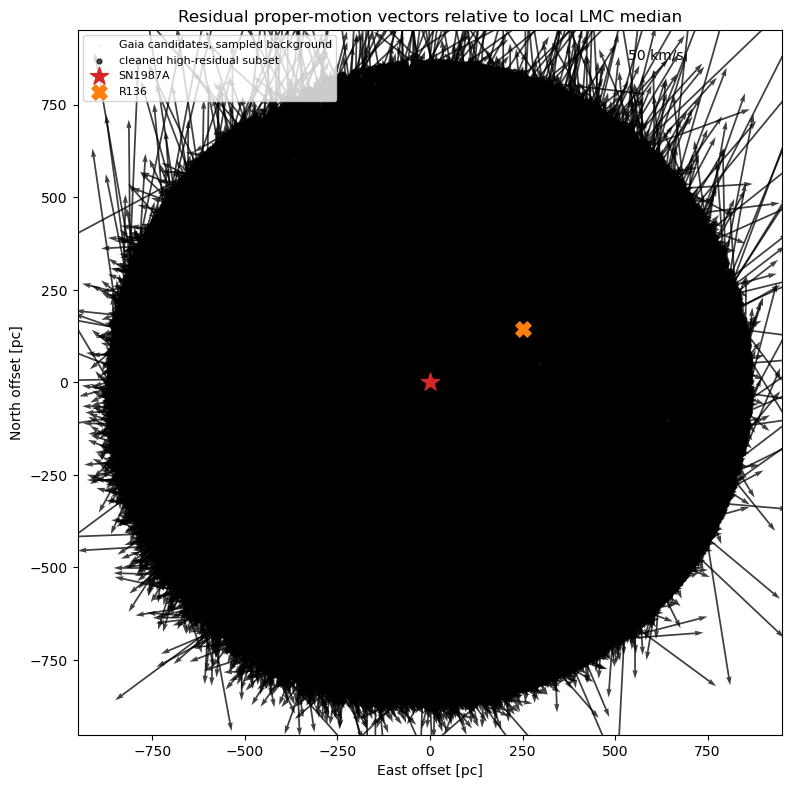

In [18]:

# Plot 6: residual proper-motion vectors on the sky, broad field
# Arrows show motion relative to the local LMC median.

arrow_time_myr = 0.2
pm_to_pc = 4.74047 * D_LMC_kpc * 1.022712 * arrow_time_myr

sub = df[
    (df["ruwe"] < 1.4) &
    (df["pmra_error"] < 0.5) &
    (df["pmdec_error"] < 0.5) &
    (df["dv_to_local_kms"] > 50)
    ].copy()

print("Stars plotted as arrows:", len(sub))

fig, ax = plt.subplots(figsize=(8, 8))

# Draw only a faint background sample, otherwise the plot is unreadable
bg = df.sample(min(len(df), 15000), random_state=1)

ax.scatter(
    bg["x_pc"],
    bg["y_pc"],
    s=2,
    alpha=0.05,
    color="tab:blue",
    label="Gaia candidates, sampled background"
)

ax.scatter(
    sub["x_pc"],
    sub["y_pc"],
    s=12,
    alpha=0.7,
    color="black",
    label="cleaned high-residual subset"
)

U = (sub["pmra"] - pmra_local) * pm_to_pc
V = (sub["pmdec"] - pmdec_local) * pm_to_pc

q = ax.quiver(
    sub["x_pc"],
    sub["y_pc"],
    U,
    V,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.0025,
    alpha=0.75,
    color="black"
)

ref_pc = 50 * 1.022712 * arrow_time_myr
ax.quiverkey(
    q,
    X=0.82,
    Y=0.94,
    U=ref_pc,
    label="50 km/s",
    coordinates="axes"
)

ax.scatter(0, 0, marker="*", s=180, color="tab:red", label="SN1987A")
ax.scatter(x_r136_pc, y_r136_pc, marker="X", s=120, color="tab:orange", label="R136")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("East offset [pc]")
ax.set_ylabel("North offset [pc]")
ax.set_title("Residual proper-motion vectors relative to local LMC median")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(fig_dir / "residual_pm_vectors_broad_cleaned.png", dpi=300)
plt.show()

star proper motion − local LMC proper motion

The residual vector field removes the bulk LMC motion and shows whether there are coherent local motions or individual runaway-like objects.

These plots are meant to separate three things: the stellar population age information from the CMD, the kinematic information from proper motions, and the spatial information from projected positions. I am using them together to see whether the environment around SN 1987A contains a coherent group of stars that could be related to the progenitor, and whether any candidate origin region stands out.